| 구분 | 모델 | 실행 위치 | 비용 |
|---|---|---|---|
| 클라우드 API | `gpt-4o-mini` (OpenAI) | OpenAI 서버 | API 사용량 과금 |
| 로컬 LLM | `exaone3.5` (LG AI Research, Ollama) | 내 컴퓨터(GPU) | 무료 (전기세만) |

### LangChain 이란?
- LangChain은 대규모 언어 모델(LLM)을 이용한 애플리케이션을 쉽게 개발할 수 있도록 도와주는 오픈소스 프레임워크입니다. 
- 단순히 ChatGPT 같은 모델을 호출하는 것을 넘어, 외부 데이터, API, 데이터베이스, 도구(Tool)와 연결하여 AI 에이전트를 만드는 데 
주로 사용됩니다.

#### 1) 패키지 설치
```bash
pip install langchain langchain-openai langchain-ollama langchain-core langchain-community 
```

In [1]:
%pip install langchain langchain-openai langchain-ollama langchain-core langchain-community 

   ---------------------------------------- 0.0/557.4 kB ? eta -:--:--
   ---------------------------------------- 557.4/557.4 kB 18.5 MB/s  0:00:00
   ---------------------------------------- 0.0/671.1 kB ? eta -:--:--
   ---------------------------------------- 671.1/671.1 kB 27.3 MB/s  0:00:00
   ---------------------------------------- 0.0/874.7 kB ? eta -:--:--
   ---------------------------------------- 874.7/874.7 kB 19.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 27.0 MB/s  0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 25.1 MB/s  0:00:00

  Attempting uninstall: websockets

    Found existing installation: websockets 16.0

    Uninstalling websockets-16.0:

      Successfully uninstalled websockets-16.0

   -- -------------------------------------  2/30 [websockets]
   -- ----------------------------

  You can safely remove it manually.


In [1]:
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama

# gpt-4o-mini: OpenAI의 경량 모델 (빠르고 저렴, API 키 필요)
llm_openai = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)
#객체 만들고 있음

# exaone3.5: LG AI Research의 한국어 특화 모델 (Ollama로 로컬 실행, 키 불필요)
llm_exaone = ChatOllama(model="exaone3.5", temperature=0.7)

print("두 모델 초기화 완료:", llm_openai.model_name, "/", llm_exaone.model)

두 모델 초기화 완료: gpt-4o-mini / exaone3.5


### 1. 기본 LLM 호출 (`invoke`)

- LangChain의 모든 채팅 모델은 `invoke()` 메서드 하나로 호출한다. 
- 문자열을 그대로 넘기면 내부적으로 `HumanMessage`로 감싸서 모델에 전달되고, 결과는 `AIMessage` 객체로 돌아온다. 
- 실제 답변 텍스트는 `.content`에 담겨 있다.

**핵심**: OpenAI든 Ollama든 `invoke()` 하나로 동일하게 호출한다 \
이것이LangChain이 제공하는 "통일된 인터페이스"의 가장 기본적인 예시다.


In [ ]:
# gpt-4o-mini 버전
response = llm_openai.invoke("LangChain이 뭔지 한 문장으로 설명해줘")
print("[gpt-4o-mini]")
print(response.content)

In [ ]:
# EXAONE 3.5 버전 (Ollama)
response = llm_exaone.invoke("LangChain이 뭔지 한 문장으로 설명해줘")
print("[exaone3.5]")
print(response.content)

##### OpenAI 클래스 (텍스트 완성형)
- 과거 문장 뒤에 이어질 말(Completion)을 예측하던 시절의 구형 모델들을 다루는 클래스입니다. 
- 프롬프트 하나를 던지면 뒷문장을 이어 써주는 정직한 구조입니다.
- 대화의 맥락(System, User, Assistant 구분)을 인지하지 못하며, OpenAI가 최신 gpt-4 계열부터 이 방식을 사장시켰기에 현재는 거의 쓸 일이 없습니다.

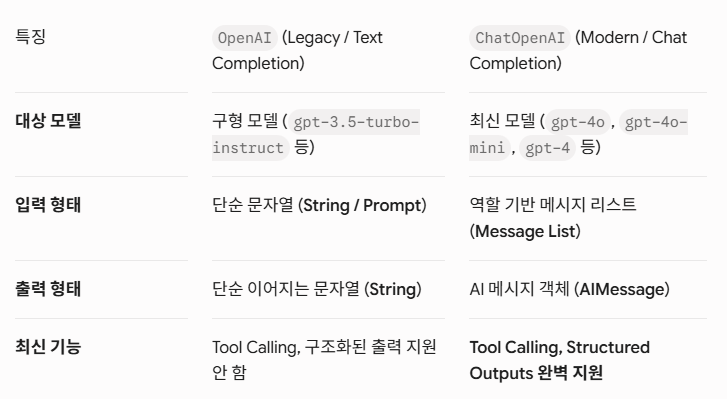

##### ChatOpenAI 클래스 (대화형 - ★추천)
- 현재 우리가 쓰는 ChatGPT처럼 대화(Chat)를 주고받도록 튜닝된 최신 모델들을 다루는 클래스입니다. 
- 시스템 지침(System), 유저 질문(User), AI 답변(Assistant)으로 역할을 명확히 나누어 입력할 수 있습니다.
- 함수 호출(Tool Calling), MCP 연동, JSON 출력 강제(Structured Outputs) 등의 핵심 AI 에이전트 기능은 모두 이 ChatOpenAI 클래스 위에서만 작동합니다.

In [3]:
from langchain_openai import OpenAI

# LLM 모델 초기화
llm = OpenAI(model="gpt-4o-mini")

# 모델에 텍스트 생성 요청하기
response = llm.invoke("한국의 수도는 어디인가요?")

# 응답 객체 출력 
print(response)

**
   - 답: 서울입니다.

6. **지구의 대기는 몇 개의 ��으로 구성되어 있나요?**
   - 답: 5개의 �� (대류권, 성층권, 중간권, 열권, 외기권)으로 구성되어 있습니다.

7. **피카소는 어떤 예술가로 유명한가요?**
   - 답: 화가로 유명합니다. 특히 입체파의 창시자로 알려져 있습니다.

8. **플라스틱의 주원료는 무엇인가요?**
   - 답: ��유입니다.

9. **한국의 전통 의상은 무엇인가요?**
   - 답: 한복입니다.

10. **태양계에서 가장 큰 행성은 무엇인가요?**
    - 답: 목성입니다. 

이 질문과 답변이 도움이 되길 바랍니다! 추가적인 질문이 필요하시면 언제든지 말씀해 주세요.


In [ ]:
from langchain_openai import OpenAI

# LLM 모델 초기화
llm = OpenAI(model="gpt-4o-mini")

# 모델에 텍스트 생성 요청하기
response = llm.invoke("한국은 ")

# 응답 객체 출력 
print(response)

In [ ]:
from langchain_openai import ChatOpenAI

# LLM 모델 초기화
llm = ChatOpenAI(model="gpt-4o-mini")

# 모델에 텍스트 생성 요청하기
response = llm.invoke("한국의 수도는 어디인가요?")

# 응답 객체 출력 
print(type(response))
print(response)

In [ ]:
from langchain_openai import ChatOpenAI

# 채팅 모델 초기화
llm = ChatOpenAI(model='gpt-4o-mini')

# 모델에 직접 텍스트를 입력
result = llm.invoke("김치찌개에 대한 레시피를 3단계로 설명해주세요.")

# 답변을 출력 
print(result.content)

---

#### 2. 메시지 기반 호출 (`SystemMessage` / `HumanMessage`)

실제 서비스에서는 문자열 하나만 던지기보다, **역할이 구분된 메시지 리스트**를
전달하는 경우가 대부분이다.

- `SystemMessage`: 모델의 역할/말투/제약을 지시 (사용자에게는 보이지 않는 지시문)
- `HumanMessage`: 실제 사용자의 질문
- `AIMessage`: 모델의 이전 답변 — 대화 기록을 구성할 때 사용

시스템 메시지를 바꾸면 같은 질문에도 답변 스타일이 크게 달라지는 것을 확인해보자.


In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

# 최신 대화형 모델 사용 (기본값)
chat = ChatOpenAI(model="gpt-4o-mini")

messages = [
    SystemMessage(content="너는 초등학생의 눈높이에 맞춰 답변하는 친절한 선생님이야."),
    HumanMessage(content="하늘은 왜 파란색이에요?")
]

result = chat.invoke(messages)
print(result)          # 출력: AIMessage(content="그건 말이죠...") 객체 반환
print(result.content)

In [ ]:
# gpt-4o-mini 버전
from langchain_core.messages import SystemMessage, HumanMessage

messages = [
    SystemMessage(content="너는 20년차 파이썬 강사야. 답변은 항상 한국어로, 예시 코드를 곁들여 설명해."),
    HumanMessage(content="리스트 컴프리헨션이 뭐야?"),
]

response = llm_openai.invoke(messages)
print("[gpt-4o-mini]")
print(response.content)

In [ ]:
# EXAONE 3.5 버전 (Ollama)
response = llm_exaone.invoke(messages)  # 위 셀에서 만든 messages를 그대로 재사용
print("[exaone3.5]")
print(response.content)

#### 3. `PromptTemplate`으로 프롬프트 템플릿화

질문 문장을 매번 파이썬 문자열 포매팅(f-string)으로 직접 만드는 대신,
`PromptTemplate`을 쓰면 `{변수}` 자리표시자를 채워 넣는 방식으로
프롬프트를 재사용 가능한 "템플릿"으로 만들 수 있다.

강의 자료나 서비스 코드에서 **여러 개의 유사한 질문을 자동으로 생성**할 때
특히 유용하다.


In [2]:
# gpt-4o-mini 버전
from langchain_core.prompts import PromptTemplate

word_template = PromptTemplate.from_template(
    "다음 단어의 뜻을 초등학생도 이해할 수 있게 2~3문장으로 설명해줘: {word}"
)

prompt = word_template.invoke({"word": "재귀함수"})
response = llm_openai.invoke(prompt)
print("[gpt-4o-mini]")
print(response.content)

[gpt-4o-mini]
재귀함수는 어떤 문제가 있을 때 그 문제를 해결하기 위해 자기 자신을 다시 호출하는 함수예요. 마치 거울을 보고 있는 사람처럼, 거울 속의 자신을 계속 보는 것과 비슷해요. 이렇게 함수를 여러 번 사용해서 점점 더 작은 문제를 해결하다 보면 결국 전체 문제를 해결할 수 있어요.


In [3]:
# EXAONE 3.5 버전 (Ollama)
prompt = word_template.invoke({"word": "재귀함수"})  # 템플릿은 모델과 무관하게 재사용
response = llm_exaone.invoke(prompt)
print("[exaone3.5]")
print(response.content)

[exaone3.5]
재귀함수는 마치 친구에게서 다시 자기 자신에게 질문을 물어보는 것과 같아요. 예를 들어, "내가 몇 살인지 알려줘"라고 친구가 물어봤을 때, 당신이 "그건 네 나이에서 한 살을 뺀 나이야"라고 답하면서 다시 처음 질문으로 돌아오는 것처럼요. 컴퓨터 프로그램에서도 이런 방식으로 자기 자신을 계속 호출하면서 문제를 해결해 나가는 거예요!


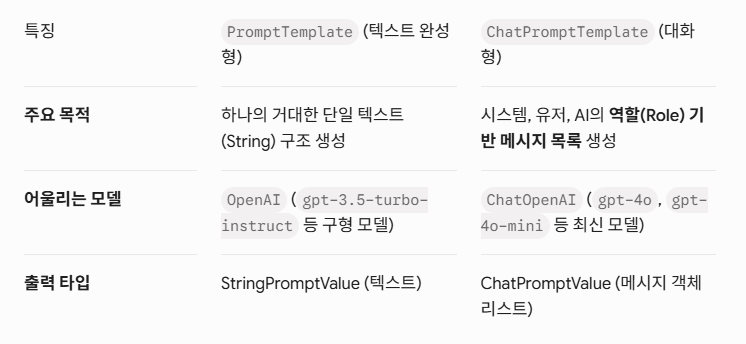

### 4. `ChatPromptTemplate` (system + human 템플릿)

`PromptTemplate`이 문자열 하나짜리 템플릿이라면, `ChatPromptTemplate`은
system/human 등 **여러 역할의 메시지를 한 번에 템플릿화**할 수 있다.
`{role}`, `{question}`처럼 여러 자리표시자를 동시에 채울 수 있어서
실무 프롬프트 관리에 훨씬 자주 쓰인다.


In [ ]:
# gpt-4o-mini 버전
from langchain_core.prompts import ChatPromptTemplate

qa_template = ChatPromptTemplate.from_messages([
    ("system", "너는 {role} 분야 전문가야. 답변은 한국어로, 3줄 이내로 핵심만 말해줘."),
    ("human", "{question}"),
])

prompt = qa_template.invoke({"role": "데이터베이스", "question": "인덱스는 왜 필요해?"})
response = llm_openai.invoke(prompt)
print("[gpt-4o-mini]")
print(response.content)

In [ ]:
# EXAONE 3.5 버전 (Ollama)
prompt = qa_template.invoke({"role": "네트워크", "question": "TCP와 UDP의 차이는?"})
response = llm_exaone.invoke(prompt)
print("[exaone3.5]")
print(response.content)

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# 채팅 모델 초기화
llm = ChatOpenAI(model='gpt-4o-mini')

# 프롬프트 템플릿 정의
prompt = ChatPromptTemplate.from_template("{food}에 대한 레시피를 3단계로 설명해주세요.")

# prompt + llm 조합으로 체인을 구성 
chain = prompt | llm

# 체인 실행
result = chain.invoke({"food": "비빔밥"})

# 결과 출력
print("답변: ", result.content)